Задание 1. Перевод в каноническую форму и расчет Slacks

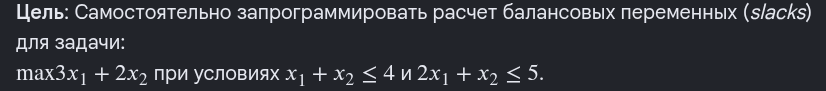

In [ ]:
import numpy as np

# Каноническая форма Ax = b.
# Вектор x содержит 4 переменные: [x1, x2, x3, x4], где x3 и x4 — это slacks.
# ЗАДАЧА: Заполните матрицу A и вектор b коэффициентами из уравнений
A = np.array([[1.0, 1.0, 1.0, 0.0], [2.0, 1.0, 0.0, 1.0]])  # x1 + x2 + x3 = 4  # 2x1 + x2 + x4 = 5
b = np.array([4.0, 5.0])


def check_point(x1, x2):
    # ЗАДАЧА: Напишите формулы для расчета x3 и x4 (балансовых переменных)
    # Помните: x3 выражается из первого ограничения, x4 — из второго.
    x3 = 4.0 - (x1 + x2)  # Подсказка для x3
    x4 = 5.0 - (2 * x1 + x2)  # <ВАШ КОД ЗДЕСЬ> (Выразите x4)

    x_full = np.array([x1, x2, x3, x4])

    # ЗАДАЧА: Напишите проверку, что Ax действительно равно b.
    # Используйте np.allclose для сравнения матричного умножения A @ x_full и вектора b
    is_correct = np.allclose(A @ x_full, b)  # <ВАШ КОД ЗДЕСЬ>

    print(f"Точка ({x1}, {x2}) -> Slacks: [x3={x3}, x4={x4}] | Ax=b верно: {is_correct}")


# Тесты для проверки вашего кода:
print("--- Проверка Задания 1 ---")
check_point(1, 1)  # Внутри (оба слэка > 0)
check_point(2, 2)  # На границе 1-го ограничения (x3 должен быть 0)
check_point(1, 3)  # В вершине/углу (оба слэка должны быть ровно 0!)

--- Проверка Задания 1 ---
Точка (1, 1) -> Slacks: [x3=2.0, x4=2.0] | Ax=b верно: True
Точка (2, 2) -> Slacks: [x3=0.0, x4=-1.0] | Ax=b верно: True
Точка (1, 3) -> Slacks: [x3=0.0, x4=0.0] | Ax=b верно: True


Задание 2. Перебор базисов и поиск вершин


--- Перебор базисов ---
Базис (0, 1): решение x_full=[1. 3.] | Допустимо (БДР): True
Базис (0, 2): решение x_full=[2.5 0. ] | Допустимо (БДР): True
Базис (0, 3): решение x_full=[4. 0.] | Допустимо (БДР): False
Базис (1, 2): решение x_full=[0. 5.] | Допустимо (БДР): False
Базис (1, 3): решение x_full=[0. 4.] | Допустимо (БДР): True
Базис (2, 3): решение x_full=[0. 0.] | Допустимо (БДР): True


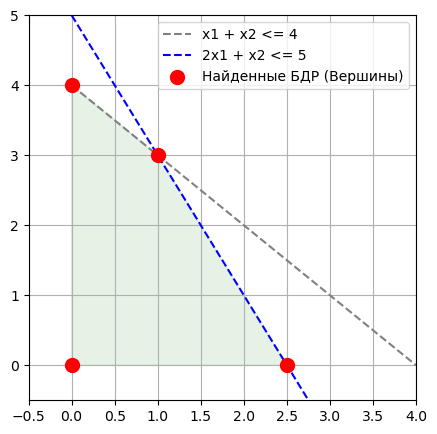

In [ ]:
from itertools import combinations

import matplotlib.pyplot as plt

A_orig = np.array([[1.0, 1.0, 1.0, 0.0], [2.0, 1.0, 0.0, 1.0]])
b = np.array([4.0, 5.0])

all_indices = [0, 1, 2, 3]  # Индексы наших 4-х переменных
vertices = []

print("\n--- Перебор базисов ---")
for base_cols in combinations(all_indices, 2):
    # Вырезаем из матрицы A только 2 столбца, соответствующие текущему базису
    B = A_orig[:, base_cols]

    # Если столбцы линейно независимы (ранг матрицы равен 2), то решение есть
    if np.linalg.matrix_rank(B) == 2:
        # ЗАДАЧА: Решите квадратную систему линейных уравнений B * x_B = b
        # Используйте функцию np.linalg.solve
        x_B = np.linalg.solve(B, b)  # <ВАШ КОД ЗДЕСЬ>

        # Собираем полный вектор x (зануляя внебазисные переменные)
        x_full = np.zeros(4)
        x_full[list(base_cols)] = x_B

        # ЗАДАЧА: Базисное решение является ДОПУСТИМЫМ (БДР), если ВСЕ компоненты x_full >= 0.
        # Напишите логическую проверку (используйте np.all с условием >= 0)
        is_feasible = np.all(x_full >= -1e-9)  # <ВАШ КОД ЗДЕСЬ>

        print(f"Базис {base_cols}: решение x_full={x_full[:2]} | Допустимо (БДР): {is_feasible}")

        if is_feasible:
            vertices.append(x_full[:2])  # сохраняем координаты x1, x2 для графика

# Код визуализации (запустится автоматически, когда вы исправите код выше)
vertices = np.array(vertices)
if len(vertices) > 0:
    plt.figure(figsize=(5, 5))
    x1_vals = np.linspace(0, 4, 100)
    plt.plot(x1_vals, 4 - x1_vals, label="x1 + x2 <= 4", color="gray", linestyle="--")
    plt.plot(x1_vals, 5 - 2 * x1_vals, label="2x1 + x2 <= 5", color="blue", linestyle="--")
    plt.scatter(vertices[:, 0], vertices[:, 1], color="red", s=100, zorder=5, label="Найденные БДР (Вершины)")
    plt.fill([0, 2.5, 1, 0], [0, 0, 3, 4], color="green", alpha=0.1)
    plt.xlim(-0.5, 4)
    plt.ylim(-0.5, 5)
    plt.legend()
    plt.grid(True)
    plt.show()

In [3]:
%pip install pyomo

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pyomo.environ as am

# Инициализация модели
model = am.ConcreteModel()

# Определение переменных решения
model.y1 = am.Var(domain=am.NonNegativeReals, bounds=(4500, 10000))  # Наушники
model.y2 = am.Var(domain=am.NonNegativeReals, bounds=(0, 14000))  # Телефоны
model.y3 = am.Var(domain=am.NonNegativeReals, bounds=(4000, 7000))  # Ноутбуки

# Целевая функция
model.profit = am.Objective(expr=5 * model.y1 + 7 * model.y2 + 12 * model.y3, sense=am.maximize)

# Ограничение по времени (мощности)
model.time_limit = am.Constraint(expr=(1 / 5000) * model.y1 + (1 / 4000) * model.y2 + (1 / 2000) * model.y3 <= 6)

# Ограничение по объему склада
model.storage_limit = am.Constraint(expr=0.03 * model.y1 + 0.05 * model.y2 + 0.22 * model.y3 <= 1500)

# Включаем суффикс двойственных переменных (для анализа чувствительности / теневых цен)
model.dual = am.Suffix(direction=am.Suffix.IMPORT)

# Запуск решения с использованием солвера cbc (или glpk)
solver = am.SolverFactory("cbc")
results = solver.solve(model)

# Вывод оптимального плана
print("--- РЕЗУЛЬТАТЫ ОПТИМИЗАЦИИ ---")
print(f"Чехлы для наушников (y1): {model.y1.value:.0f} шт.")
print(f"Чехлы для телефонов (y2): {model.y2.value:.0f} шт.")
print(f"Чехлы для ноутбуков (y3): {model.y3.value:.0f} шт.")
print(f"Максимальная еженедельная чистая прибыль: ${model.profit():.2f}")

print("\n--- АНАЛИЗ ЧУВСТВИТЕЛЬНОСТИ (ТЕНЕВЫЕ ЦЕНЫ) ---")
print(f"Теневая цена складского пространства: {model.dual[model.storage_limit]:.2f}")
print(f"Теневая цена рабочего времени: {model.dual[model.time_limit]:.2f}")

--- РЕЗУЛЬТАТЫ ОПТИМИЗАЦИИ ---
Чехлы для наушников (y1): 10000 шт.
Чехлы для телефонов (y2): 6400 шт.
Чехлы для ноутбуков (y3): 4000 шт.
Максимальная еженедельная чистая прибыль: $142800.00

--- АНАЛИЗ ЧУВСТВИТЕЛЬНОСТИ (ТЕНЕВЫЕ ЦЕНЫ) ---
Теневая цена складского пространства: 140.00
Теневая цена рабочего времени: -0.00
